### Analyze bout length to determine what cutoff/threshold times to use.

In [1]:
import os
import sys

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(PROJECT_ROOT)

print(PROJECT_ROOT)

from experiment_class import Experiment
from bouts_extension import *
from Reward_Training_Competition.Reward_Competition.rc_extension import Reward_Competition

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\yezon\Padilla-Coreano_Lab\UMAP\Fiber_Photometry_revisions


In [2]:
# NAc
# experiment_path = r"C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\Rig Data\NAc"
# csv_base_path = r"C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\NAc"
# brain_region = '#15616F'

# NAc: #15616F
# mPFC: #FFAF00

# mPFC
# experiment_path = r"C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\Rig Data\mPFC"

# test experiment path
experiment_path = r"C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\test_rig_data"
csv_base_path = r"C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\mPFC"

# All data
# experiment_path = r"C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\Rig Data\All_data"
# csv_base_path = r"C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\Full_data"
brain_region = '#FFAF00'

In [3]:
# experiment = Experiment(experiment_path, csv_base_path)
experiment = Reward_Competition(experiment_folder_path=experiment_path, behavior_folder_path=csv_base_path)

experiment.rtc_processing()

read from t=0s to t=2042.75s
read from t=0s to t=2042.75s
Processing trial pp1-250203-094756...
Processing trial pp3-250203-094756...


In [5]:
bout_definitions = [
    {'prefix': 'subject_behavior', 'behavior': 'Competition Bout', 'subject': 'Subject'},
    {'prefix': 'agent_behavior', 'behavior': 'Competition Bout', 'subject': 'Social Agent'}
]

experiment.group_extract_manual_annotations2(bout_definitions,first_only=False, cue=False)

C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\mPFC\pp1-250203-094756.csv
After combining # bouts: 45
44
C:\Users\yezon\Padilla-Coreano_Lab\Albert_Cohort_3\Reward_Comp\Data\BORIS-nonreward\mPFC\pp3-250203-094756.csv
After combining # bouts: 72
72


In [7]:
exp_dict = get_trial_dataframes(experiment)

In [8]:
metadata_df = create_metadata_dataframe2(exp_dict, behavior="Competition Bout", desired_bouts=None)

In [9]:
total_avg_bout_duration = metadata_df["Average Bout Duration"].mean()
print(f"Total Average Bout Duration: {total_avg_bout_duration:.4f}")

Total Average Bout Duration: 3.6437


### Distribution of Durations of competition bouts

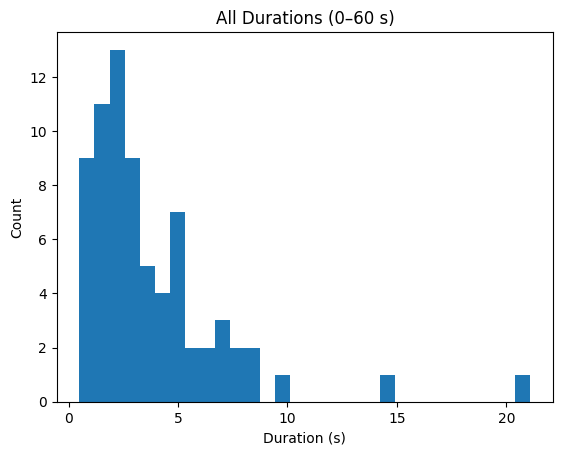

In [10]:
all_df = pd.concat(exp_dict.values(), ignore_index=True)

filtered = all_df[all_df["Duration (s)"] <= 60]

plt.hist(filtered["Duration (s)"], bins=30)
plt.title("All Durations (0–60 s)")
plt.xlabel("Duration (s)")
plt.ylabel("Count")
plt.show()

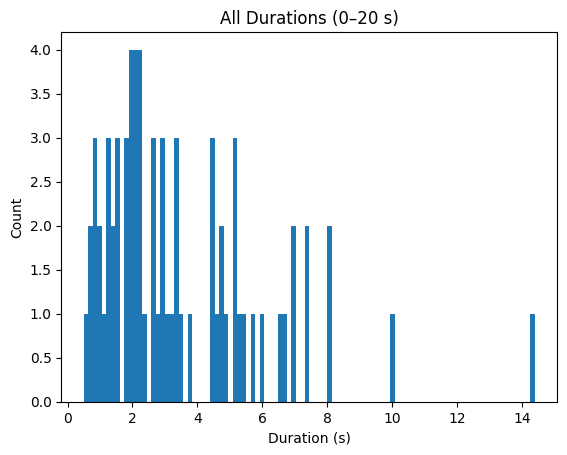

In [11]:
all_df = pd.concat(exp_dict.values(), ignore_index=True)

filtered = all_df[all_df["Duration (s)"] <= 20]

plt.hist(filtered["Duration (s)"], bins=100)
plt.title("All Durations (0–20 s)")
plt.xlabel("Duration (s)")
plt.ylabel("Count")
plt.show()

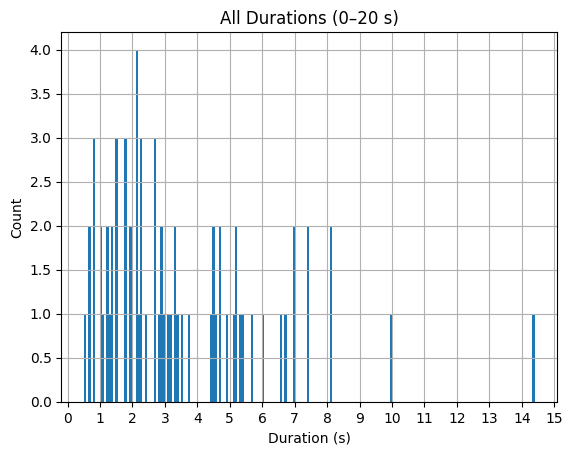

In [12]:
from matplotlib.ticker import MultipleLocator
filtered = all_df[all_df["Duration (s)"] <= 20]

plt.hist(filtered["Duration (s)"], bins=200)
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(1))   
plt.title("All Durations (0–20 s)")
plt.xlabel("Duration (s)")
plt.ylabel("Count")
plt.grid(True)
plt.show()

### Global ITI. ITI between bouts regardless of who initiated

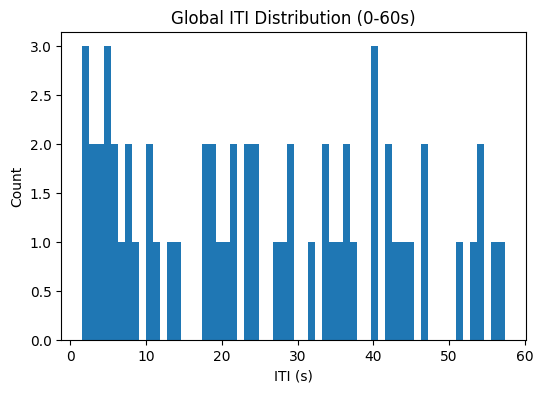

In [13]:
all_iti = []

for df in exp_dict.values():
    if df is None or not hasattr(df, "columns"):
        continue

    iti = df["Event_Start"].values[1:] - df["Event_End"].values[:-1]
    all_iti.extend(iti)

all_iti = np.array(all_iti)
all_iti60 = all_iti[(all_iti >= 0) & (all_iti <= 60)]
plt.figure(figsize=(6,4))

plt.hist(all_iti60, bins=60)

plt.xlabel("ITI (s)")
plt.ylabel("Count")
plt.title("Global ITI Distribution (0-60s)")

plt.show()

Text(0.5, 1.0, 'Global ITI Distribution (0-90s)')

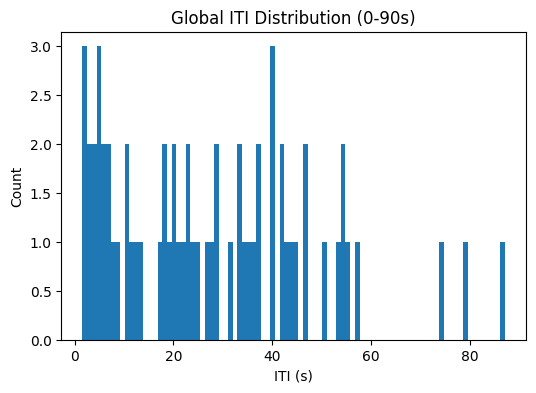

In [14]:
all_iti90 = all_iti[(all_iti >= 0) & (all_iti <= 90)]
plt.figure(figsize=(6,4))

plt.hist(all_iti90, bins=90)

plt.xlabel("ITI (s)")
plt.ylabel("Count")
plt.title("Global ITI Distribution (0-90s)")

Text(0.5, 1.0, 'Global ITI Distribution (0-20s)')

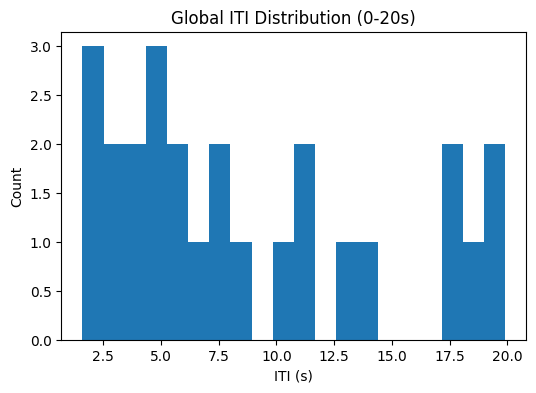

In [15]:
all_iti20 = all_iti[(all_iti >= 0) & (all_iti <= 20)]
plt.figure(figsize=(6,4))

plt.hist(all_iti20, bins=20)

plt.xlabel("ITI (s)")
plt.ylabel("Count")
plt.title("Global ITI Distribution (0-20s)")

Text(0.5, 1.0, 'Global ITI Distribution (0-5s)')

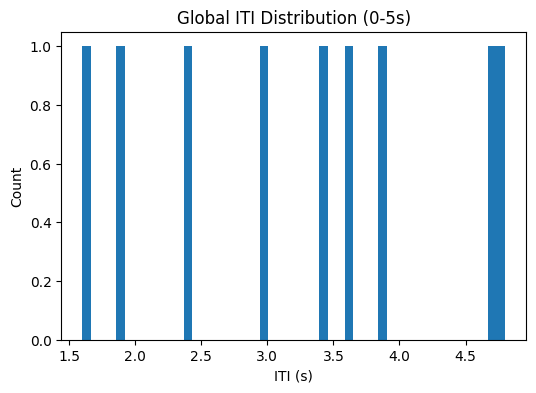

In [16]:
all_iti20 = all_iti[(all_iti >= 0) & (all_iti <= 5)]
plt.figure(figsize=(6,4))

plt.hist(all_iti20, bins=50)

plt.xlabel("ITI (s)")
plt.ylabel("Count")
plt.title("Global ITI Distribution (0-5s)")

Text(0.5, 1.0, 'Global ITI Distribution (0-3s)')

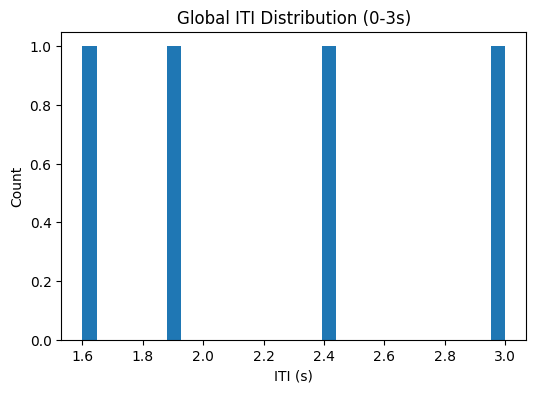

In [17]:
all_iti20 = all_iti[(all_iti >= 0) & (all_iti <= 3)]
plt.figure(figsize=(6,4))

plt.hist(all_iti20, bins=30)

plt.xlabel("ITI (s)")
plt.ylabel("Count")
plt.title("Global ITI Distribution (0-3s)")

### Separate ITI based on subject or agent initiator.

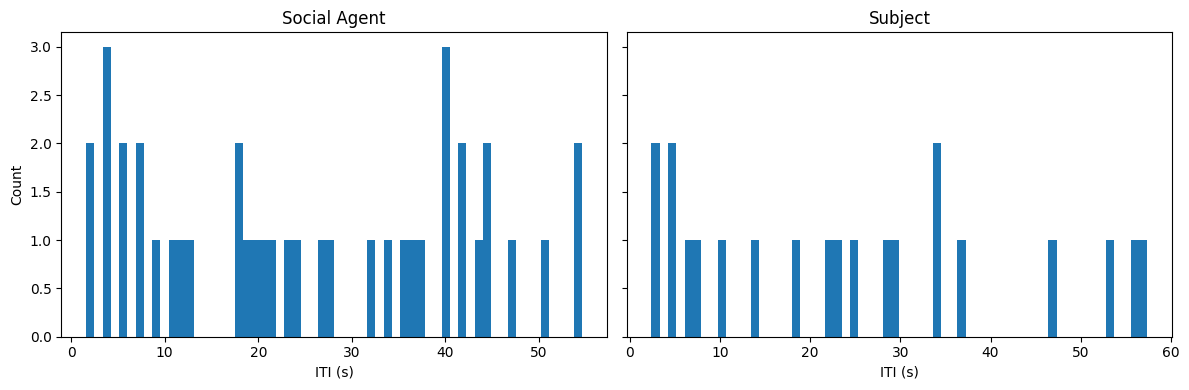

In [22]:
def compute_separate_iti_df(exp_dict):
    rows = []

    for trial_name, df in exp_dict.items():

        if df is None or not hasattr(df, "columns"):
            continue

        if "Initiators" not in df.columns:
            continue

        for group in df["Initiators"].unique():

            sub_df = df[df["Initiators"] == group].copy()

            if "Event_Start" not in sub_df.columns or "Event_End" not in sub_df.columns:
                continue

            sub_df = sub_df.sort_values("Event_Start")

            iti = sub_df["Event_Start"].values[1:] - sub_df["Event_End"].values[:-1]

            for val in iti:
                rows.append({
                    "Trial": trial_name,
                    "Group": group,
                    "ITI": val
                })

    return pd.DataFrame(rows)

iti_df = compute_separate_iti_df(exp_dict)

iti_df1 = iti_df[(iti_df["ITI"] >= 0) & (iti_df["ITI"] <= 60)]

# Histogram
groups = iti_df1["Group"].unique()

fig, axes = plt.subplots(1, len(groups), figsize=(12, 4), sharey=True)

for ax, group in zip(axes, groups):
    subset = iti_df1[iti_df1["Group"] == group]
    
    ax.hist(subset["ITI"], bins=60)
    ax.set_title(group)
    ax.set_xlabel("ITI (s)")

axes[0].set_ylabel("Count")

plt.tight_layout()
plt.show()

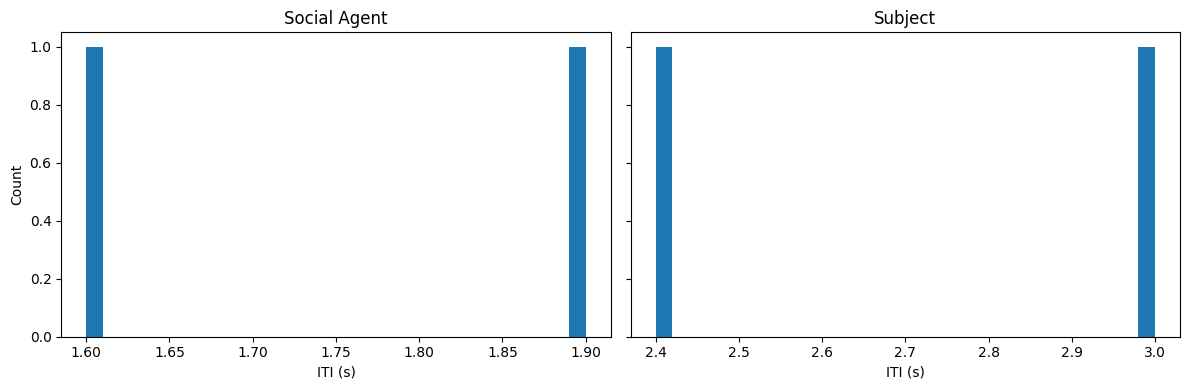

In [23]:
iti_df1 = iti_df[(iti_df["ITI"] >= 0) & (iti_df["ITI"] <= 3)]

# Histogram
groups = iti_df1["Group"].unique()

fig, axes = plt.subplots(1, len(groups), figsize=(12, 4), sharey=True)

for ax, group in zip(axes, groups):
    subset = iti_df1[iti_df1["Group"] == group]
    
    ax.hist(subset["ITI"], bins=30)
    ax.set_title(group)
    ax.set_xlabel("ITI (s)")

axes[0].set_ylabel("Count")

plt.tight_layout()
plt.show()